In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json
import sys

In [2]:
data = {}

output_dir = Path('outputs')
for file in output_dir.glob('stopping_bandwidth_Qx*_Qy*.json'):
    with open(file, 'r') as f:
        Qx = float(file.stem.split('_')[2][2:])
        Qy = float(file.stem.split('_')[3][2:])
        data[(Qx, Qy)] = json.load(f)

In [13]:
def get_survival_fraction(data, Qx, Qy):
    key = (Qx, Qy)
    if key in data:
        return np.count_nonzero(np.array(data[key]['state']) > 0) / len(data[key]['state'])
    else:
        return None

In [16]:
survival_fractions = {key: get_survival_fraction(data, *key) for key in data.keys()}
for (Qx, Qy), survival_fraction in sorted(survival_fractions.items()):
    print(f"Qx={Qx}, Qy={Qy} => Survival Fraction: {survival_fraction:.2%}")

Qx=20.005, Qy=20.18 => Survival Fraction: 22.60%
Qx=20.01, Qy=20.18 => Survival Fraction: 34.60%
Qx=20.015, Qy=20.18 => Survival Fraction: 67.00%
Qx=20.02, Qy=20.18 => Survival Fraction: 75.00%
Qx=20.025, Qy=20.18 => Survival Fraction: 88.00%
Qx=20.03, Qy=20.18 => Survival Fraction: 91.20%
Qx=20.035, Qy=20.18 => Survival Fraction: 95.80%
Qx=20.04, Qy=20.18 => Survival Fraction: 97.60%
Qx=20.045, Qy=20.18 => Survival Fraction: 100.00%
Qx=20.05, Qy=20.18 => Survival Fraction: 100.00%


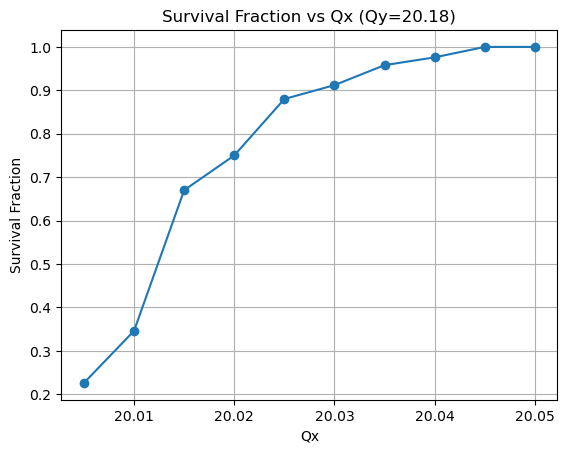

In [17]:
fig, ax = plt.subplots()
Qx_values = sorted(set(key[0] for key in survival_fractions.keys()))
survival_values = [survival_fractions[(Qx, 20.18)] for Qx in Qx_values]
ax.plot(Qx_values, survival_values, marker='o')
ax.set_xlabel('Qx')
ax.set_ylabel('Survival Fraction')
ax.set_title('Survival Fraction vs Qx (Qy=20.18)')
ax.grid()